# 03 — Evaluation et interpretabilite

Comparaison des 6 modeles sur les metriques adaptees au desequilibre de classes,
puis analyse d'interpretabilite (importance des features, SHAP) du modele final.

In [1]:
import pandas as pd
results_df = pd.read_csv('../data/model_comparison.csv', index_col=0)
results_df.sort_values('pr_auc', ascending=False)

,precision,recall,f1,roc_auc,pr_auc,temps_entrainement_s,n_entrainement,n_evaluation
XGBoost,0.9801,0.9076,0.9425,0.9806,0.9829,12.9,290855.0,72714.0
Random_Forest,0.9891,0.8927,0.9384,0.9771,0.9806,40.9,290855.0,72714.0
Arbre_de_decision,0.9616,0.9155,0.9379,0.9743,0.9767,6.1,290855.0,72714.0
KNN,0.9674,0.8977,0.9312,0.9722,0.9737,5.8,40000.0,15000.0
Regression_logistique,0.9159,0.8933,0.9044,0.9447,0.9492,7.0,290855.0,72714.0
SVM,0.9837,0.8706,0.9237,0.9552,0.9484,31.3,8000.0,72714.0


## Visualisation comparative

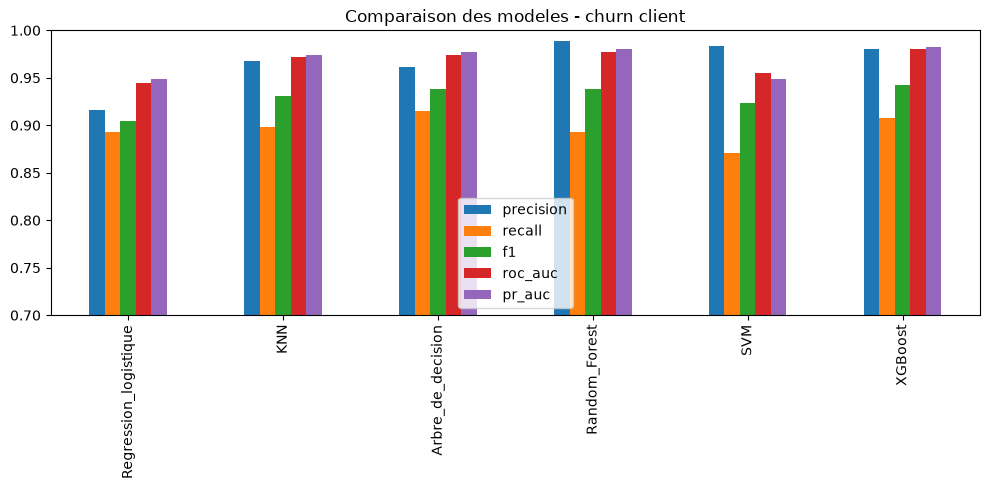

In [2]:
import matplotlib.pyplot as plt

metrics_to_plot = ['precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
ax = results_df[metrics_to_plot].plot(kind='bar', figsize=(10, 5))
ax.set_ylim(0.7, 1.0)
ax.set_title('Comparaison des modeles - churn client')
plt.tight_layout()
plt.savefig('../data/models_comparison.png', dpi=120)
plt.show()

## Rapport de classification du modele final

In [3]:
import json
with open('../data/best_model.json') as f:
    best = json.load(f)
print('Modele final :', best['best_model'])
print(best['metrics'])
print(open(f"../data/{best['best_model']}_classification_report.txt").read())

Modele final : XGBoost
{'precision': 0.9801, 'recall': 0.9076, 'f1': 0.9425, 'roc_auc': 0.9806, 'pr_auc': 0.9829, 'temps_entrainement_s': 12.9, 'n_entrainement': 290855, 'n_evaluation': 72714}
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     40354
           1       0.98      0.91      0.94     32360

    accuracy                           0.95     72714
   macro avg       0.96      0.95      0.95     72714
weighted avg       0.95      0.95      0.95     72714



## Matrice de confusion

In [4]:
import numpy as np
cm = np.loadtxt(f"../data/{best['best_model']}_confusion_matrix.csv", delimiter=',')
cm

array([[39759.,   595.],
       [ 2991., 29369.]])

## ⚠️ Fuites de donnees ecartees avant modelisation

- `nb_comptes_clos` : definit litteralement la cible (`churn = nb_comptes_clos == nb_comptes`).
- `nb_devises` : artefact de completude des donnees produit (`nb_devises = 0` -> `churn = 1`
  dans ~100% des cas pour 38% des clients), sans lien comportemental reel. Un test de
  sensibilite confirme une performance quasi identique sans cette variable.

Voir `comparison.md` et les commentaires dans `src/train.py` pour le detail complet
de l'investigation.

## Importance des features (XGBoost) et SHAP

La cellule suivante exécute `src/interpretability.py`, qui a besoin de `models/model_final.joblib` (produit par `02_entrainement.ipynb`). Elle génère `data/feature_importance.png`, `data/shap_summary.png`, `data/feature_importance.csv` et `data/shap_importance.csv`.

In [5]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, '../src/interpretability.py'],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError('interpretability.py a échoué — voir le message ci-dessus.')

Top 10 features (SHAP):
                        feature  mean_abs_shap
                  montant_total       1.676529
   anciennete_compte_moy_annees       1.502169
            a_epargne_placement       0.886908
   anciennete_compte_max_annees       0.606644
                     nb_comptes       0.586187
       anciennete_client_annees       0.442503
                    solde_moyen       0.360326
                    solde_total       0.345611
jours_depuis_derniere_revue_moy       0.185447
                            age       0.161645



In [6]:
import pandas as pd
imp = pd.read_csv('../data/feature_importance.csv')
imp.head(15)

,feature,importance
0,a_epargne_placement,0.492170
1,montant_total,0.312907
2,anciennete_compte_moy_annees,0.052350
3,nb_produits_distincts,0.009981
4,nb_comptes,0.008129
5,a_credit,0.008008
6,anciennete_client_annees,0.007775
7,taux_fixe_moyen,0.006633
8,anciennete_compte_max_annees,0.006132
9,partyclass_Retail,0.005598


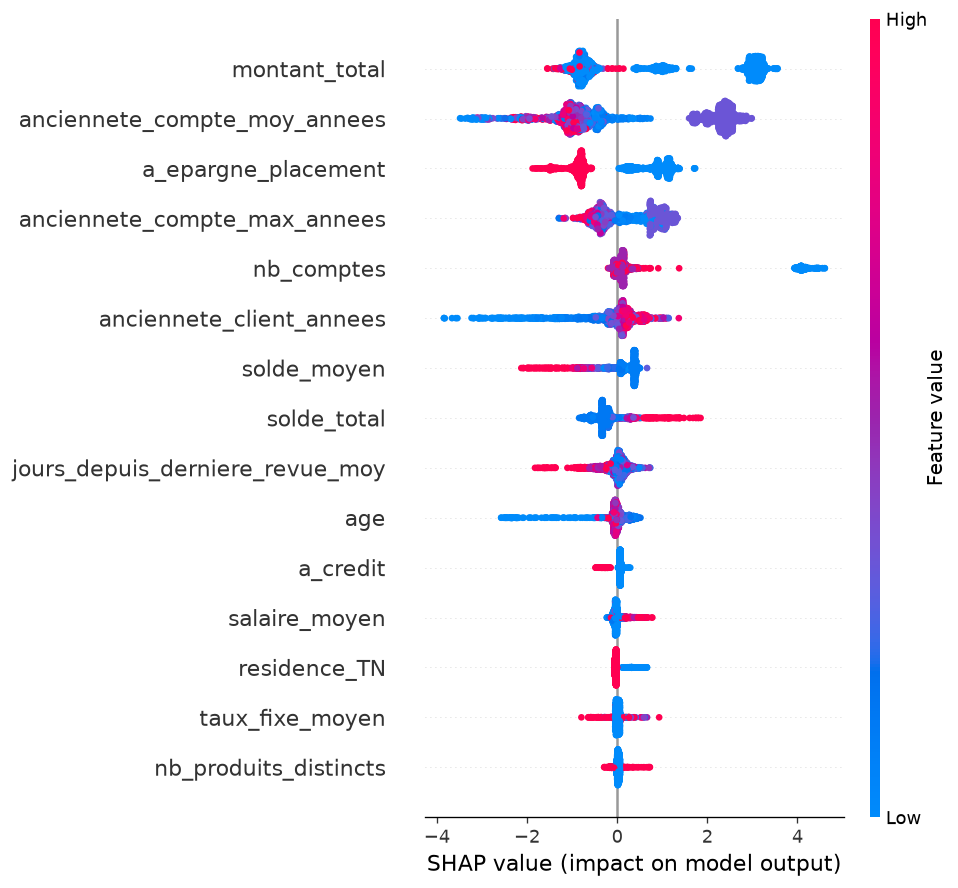

In [7]:
from IPython.display import Image
Image('../data/shap_summary.png')

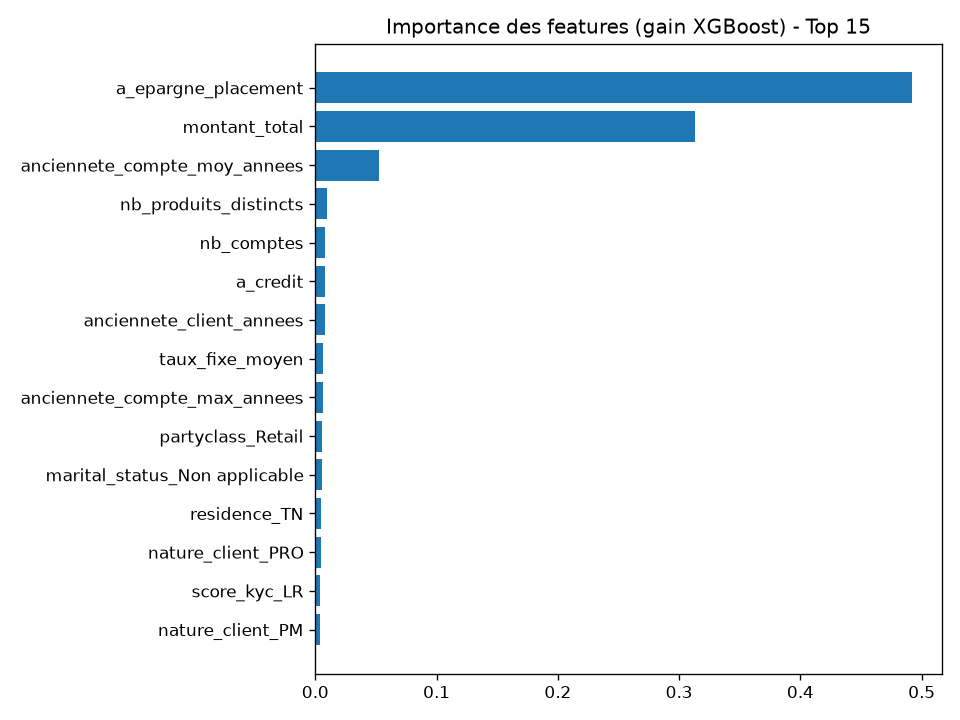

In [8]:
from IPython.display import Image
Image('../data/feature_importance.png')

## Conclusion

**XGBoost** est retenu comme modele final (PR-AUC 0.983, F1 0.942). Les facteurs les plus predictifs identifies (montant total des produits, anciennete des comptes, detention d'un produit epargne/placement) sont coherents avec l'intuition metier et actionnables pour des actions de retention ciblées. Voir `comparison.md` a la racine du dossier pour le tableau comparatif complet, la justification du modele retenu, et le detail des fuites de donnees ecartees.